# GBM Cell-Cell Communication

This notebook runs cell-cell communication analysis and summarizes cluster-specific receiver communication markers.


## Setup


In [ ]:
from pathlib import Path
import pickle
import sys

import scanpy as sc
from IPython.display import display

UNIG_SRC = Path('/home/nas3/biod/yangchenghui/proj2/UniG_master/src')
if str(UNIG_SRC) not in sys.path:
    sys.path.insert(0, str(UNIG_SRC))

import unig as ug
ug.comm.install_numpy_compat_aliases()
ug.comm.register_anndata_null_reader()


/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/ctxcore/__init__.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


<function unig.tasks.comm.register_anndata_null_reader.<locals>.read_null(elem, *, _reader)>

In [2]:
PROJECT_DIR = Path('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM')
DOWNSTREAM_CCC = PROJECT_DIR / 'downstream_CCC'
DOWNSTREAM_TRAIT = PROJECT_DIR / 'downstream_trait'
STCASE_DB_DIR = Path('/home/nas3/biod/yangchenghui/proj2/STCase-main/STCaseDB')

ST_RNA_H5AD = PROJECT_DIR / 'SIMBA_result/GBM_st_RNA_adata.h5ad'
UNIG_ADATA_DICT = PROJECT_DIR / 'UniG_output/HumanGBM_UniG_adata_dict.pkl'
OUTPUT_DIR = DOWNSTREAM_CCC / 'output'
FIGURE_DIR = DOWNSTREAM_CCC / 'figures'
UNIG_CCC_OUTPUT = OUTPUT_DIR / 'unig_ccc_spatial_communication.h5ad'

UNIG_NETWORK_PATH = DOWNSTREAM_TRAIT / 'regulatory_result/GBM_TF_Gene_Regulatory_Network_clean.csv'
UNIG_TF_ACTIVITY_PATH = DOWNSTREAM_TRAIT / 'regulatory_result/GBM_TF_regulatory_activity_adata.h5ad'

CLUSTER_KEY = 'type'
CLUSTER_VALUE = '1'
TOP_LR_PER_CLUSTER = 20
TOP_PATHWAY_PER_CLUSTER = 20
TOP_N_CLUSTER_MARKERS = 20
RANK_METHOD = 'wilcoxon'
MIN_PCT_RECEIVER_SPOTS = 0.05
MAX_PVAL_ADJ = 0.05
MIN_LOGFOLDCHANGE = 0.0
FILL_TOP_N_WITH_UNFILTERED = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


## Load Data


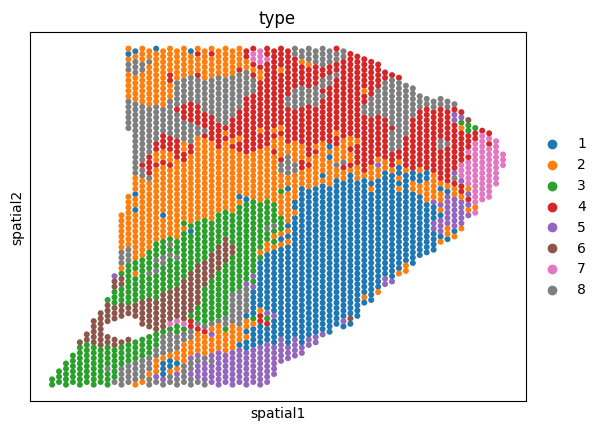

In [3]:
db_interaction, db_complex = ug.comm.load_unig_ccc_databases(STCASE_DB_DIR, species='Human')

stRNA_adata = sc.read_h5ad(ST_RNA_H5AD)
with open(UNIG_ADATA_DICT, 'rb') as handle:
    dict_adata = pickle.load(handle)

stRNA_adata = ug.comm.attach_unig_clusters_to_spatial_adata(
    stRNA_adata,
    dict_adata,
    entity_key='C',
    cluster_key='mclust',
    output_key=CLUSTER_KEY,
)

sc.pl.embedding(stRNA_adata, basis='spatial', color=[CLUSTER_KEY], size=75)


## Run UniG CCC


In [4]:
ccc_adata = ug.comm.run_unig_ccc(
    stRNA_adata,
    db_interaction,
    db_complex,
    method='Hill',
    ct_key=CLUSTER_KEY,
    if_hvg=False,
    if_filter=False,
    if_self=True,
    if_intra=True,
    if_stringent=False,
    intra_method='unig',
    unig_network_path=str(UNIG_NETWORK_PATH),
    unig_tf_activity_path=str(UNIG_TF_ACTIVITY_PATH),
    min_regulon_targets=10,
    background_number=1000,
    threads=10,
    scope=6,
    min_exp=0.1,
    cutoff=0.05,
)
ccc_adata = ug.comm.sanitize_uns_keys_for_h5ad(ccc_adata)
ccc_adata.write_h5ad(UNIG_CCC_OUTPUT)
ccc_adata

##################################################################
Now start to calulate radius
The radius is: 2.0
##################################################################
Now start to get LR pair
The number of keep LR pair is 2626
##################################################################
get_LR_gene_exp
##################################################################
get_close_gene
##################################################################
Now start to get true weight matirx
Now processing the unsecreted
Computed weight matrix process: |██████████████████████████████| 100%
Now processing the secreted
Computed weight matrix process: |██████████████████████████████| 100%
##################################################################
Now start to permutation test
Permutation test and filtering process: |██████████████████████████████| 100%
##################################################################
Now  start to add intracellular signals
Run UniG G

AnnData object with n_obs × n_vars = 2768 × 24587
    obs: 'RNA_cluster', 'COMBO_cluster', 'cell_type', 'leiden', 'type'
    var: 'feature_type', 'n_cells', 'moran_I', 'spatial_qval', 'spatially_variable', 'spatially_variable_rank'
    uns: 'COMBO_cluster_colors', 'RNA_cluster_colors', 'cell_type_colors', 'leiden', 'leiden_colors', 'log1p', 'moranI', 'neighbors', 'pca', 'spatial_neighbors', 'svg_top_genes', 'umap', 'type_colors', 'radius', 'LR_pair_information', 'LR_gene_complex_information', 'LR_gene_complex_exp', 'LR_close_gene', 'LR_close_gene_exp', 'LR_cell_weight', 'Cell_neighbors', 'LR_permutation_count', 'GRN_res', 'type_list', 'LR_celltype_weight', 'LR_celltype_mean_weight', 'LR_celltype_edge_num', 'LR_celltype_aggregate_weight', 'LR_pathway_celltype_weight', 'LR_pathway_celltype_mean_weight', 'LR_pathway_celltype_edge_num', 'LR_pathway_celltype_count', 'LR_pathway_cell_weight', '_unig_h5ad_key_map'
    obsm: 'X_pca', 'X_umap', 'spatial', 'distances'
    varm: 'PCs'
    obsp: '

## Inspect One LR Pair


In [5]:
lr_cell_score = ug.comm.lr_cell_level_score(ccc_adata, 'IL6|COMPLEX:IL6R_IL6ST')
lr_celltype_weight = ug.comm.lr_celltype_weight(ccc_adata, 'IL6|COMPLEX:IL6R_IL6ST')
lr_celltype_mean_weight = ug.comm.lr_celltype_mean_weight(ccc_adata, 'IL6|COMPLEX:IL6R_IL6ST')

display(lr_cell_score.iloc[:5, :5])
display(lr_celltype_weight)
display(lr_celltype_mean_weight)


cell_barcode,AACACTTGGCAAGGAA-1,AACAGGATTCATAGTT-1,AACAGGTTATTGCACC-1,AACAGGTTCACCGAAG-1,AACAGTCAGGCTCCGC-1
cell_barcode,,,,,
AACACTTGGCAAGGAA-1,0.0,0.0,0.0,0.0,0.0
AACAGGATTCATAGTT-1,0.0,0.0,0.0,0.0,0.0
AACAGGTTATTGCACC-1,0.0,0.0,0.0,0.0,0.0
AACAGGTTCACCGAAG-1,0.0,0.0,0.0,0.0,0.0
AACAGTCAGGCTCCGC-1,0.0,0.0,0.0,0.0,0.0


,1,2,3,4,5,6,7,8
1,27.71394,3.358118,0.480430,0.000000,1.491237,0.00000,0.000000,5.932157
2,0.00000,7.225159,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
3,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
4,0.00000,0.000000,0.000000,11.931861,0.000000,0.00000,0.817999,1.168698
5,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
6,0.00000,0.000000,6.041515,0.000000,0.000000,4.53848,0.000000,0.000000
7,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
8,0.00000,13.815074,0.000000,2.440374,0.000000,0.00000,0.000000,27.755155


,1,2,3,4,5,6,7,8
1,0.692849,0.839530,0.480430,0.000000,0.372809,0.000000,0.000000,0.593216
2,0.000000,0.903145,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.000000,1.084715,0.000000,0.000000,0.817999,0.584349
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.000000,0.000000,0.464732,0.000000,0.000000,0.907696,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.921005,0.000000,0.813458,0.000000,0.000000,0.000000,0.816328


## Cell-Type Communication Summary


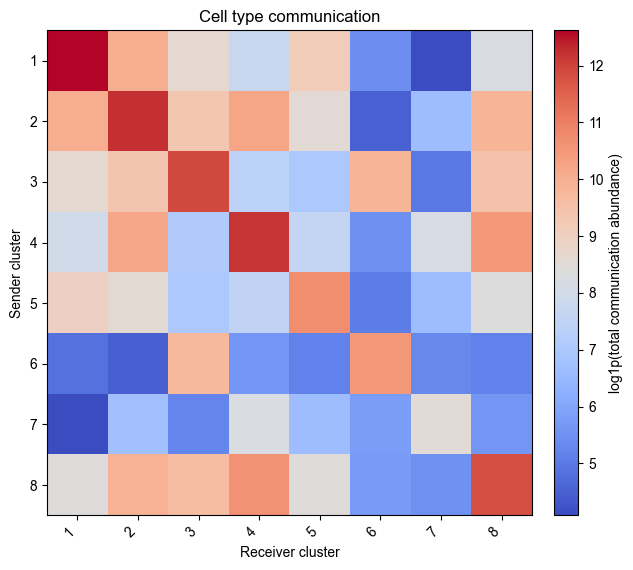

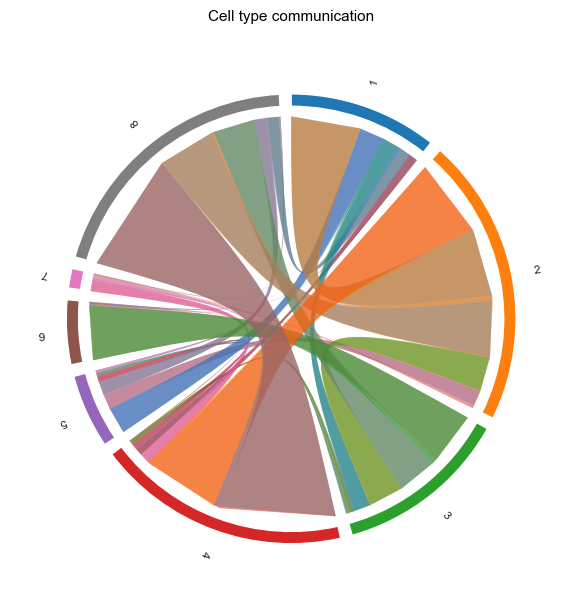

,1,2,3,4,5,6,7,8
1,302210.847358,22625.761474,5852.964303,2377.214751,9144.281252,227.207852,60.468611,3640.261195
2,23195.710100,204112.897894,11402.424424,26561.465031,5121.499861,88.925459,756.141121,18536.445575
3,5676.812038,11603.603852,149570.133751,1600.103572,1099.658208,18878.734998,141.422364,12934.760686
4,2973.920673,25782.043655,1197.605658,191634.847352,1998.935083,239.273985,3411.882671,36984.150737
5,7960.028568,5240.611898,1097.966499,1827.289878,44862.364349,155.653286,759.431360,4126.787259
6,125.197378,86.505957,17093.499376,281.079805,174.018222,36383.867660,201.138303,176.465152
7,58.490746,833.832435,185.109399,3736.520692,764.578254,324.541003,4854.830043,272.775191
8,4428.867508,20067.357136,14793.091089,42061.577724,4665.381210,313.302479,246.206313,135773.111016


In [14]:
ccc_adata = sc.read_h5ad('/home/nas3/biod/yangchenghui/proj2/proj2_on_GBM/downstream_CCC/output/stRNA_adata_stringent.h5ad')
celltype_comm_mtx = ug.comm.celltype_communication_matrix(ccc_adata)
ug.comm.plot_celltype_communication_heatmap(
    celltype_comm_mtx,
    out_pdf=FIGURE_DIR / 'celltype_celltype_communication_heatmap.pdf',
    title='Cell type communication',
)
ug.comm.plot_chord_diagram_nature(
    celltype_comm_mtx,
    out_pdf=FIGURE_DIR / 'celltype_celltype_communication_chord.pdf',
    title='Cell type communication',
    remove_self=True,
    sector_size='strength',
    ribbon_alpha=0.55,
    figsize=(6.2, 6.2),
    color_adata=ccc_adata,
    color_key=CLUSTER_KEY,
)

celltype_comm_mtx


## Receiver LR Markers


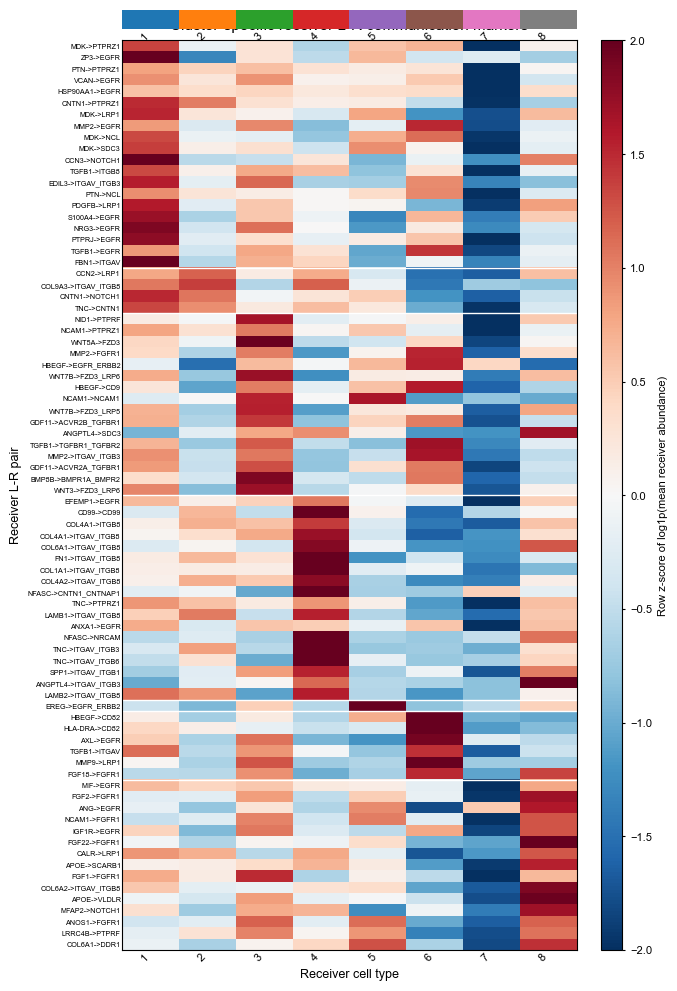

,cluster,LR_pair,scores,logfoldchanges,pvals,pvals_adj,pct_receiver_spots_positive,pct_receiver_spots_positive_rest,LR_label,mean_receiver_abundance
0,1,MDK|PTPRZ1,21.514687,1.162899,1.134442e-102,2.979045e-99,0.979626,0.854520,MDK->PTPRZ1,3.787684
1,1,ZP3|EGFR,20.869009,1.744823,1.024355e-96,1.344978e-93,0.872666,0.493804,ZP3->EGFR,2.871840
2,1,PTN|PTPRZ1,19.267469,0.489747,1.007446e-82,8.818510e-80,0.994907,0.947223,PTN->PTPRZ1,30.778883
3,1,VCAN|EGFR,18.081697,0.325564,4.441920e-73,2.916121e-70,1.000000,0.998164,VCAN->EGFR,38.339817
4,1,HSP90AA1|EGFR,17.012552,0.134760,6.628686e-65,3.481386e-62,1.000000,0.994493,HSP90AA1->EGFR,9.176902
5,1,CNTN1|PTPRZ1,15.816292,0.864696,2.402301e-56,1.051407e-53,0.937182,0.782010,CNTN1->PTPRZ1,2.731329
6,1,MDK|LRP1,15.053961,1.326564,3.251677e-51,1.219843e-48,0.799660,0.567692,MDK->LRP1,3.842398
7,1,MMP2|EGFR,14.742468,0.891405,3.439801e-49,1.129115e-46,0.925297,0.813676,MMP2->EGFR,4.749737
8,1,MDK|NCL,14.359327,1.197648,9.312724e-47,2.717246e-44,0.816638,0.572740,MDK->NCL,2.257907
9,1,MDK|SDC3,13.374671,1.191285,8.502903e-41,2.232862e-38,0.789474,0.554842,MDK->SDC3,3.490392


In [15]:
lr_spot_receiver_mtx = ug.comm.receiver_lr_spot_matrix(ccc_adata)
(
    cluster_specific_lr_pairs,
    _,
    lr_receiver_mean_by_type,
    _,
) = ug.comm.rank_cluster_specific_lr_pairs_scanpy(
    lr_spot_receiver_mtx,
    ccc_adata,
    cluster_key=CLUSTER_KEY,
    top_n=TOP_LR_PER_CLUSTER,
    method=RANK_METHOD,
    min_pct=MIN_PCT_RECEIVER_SPOTS,
    max_pval_adj=MAX_PVAL_ADJ,
    min_logfoldchange=MIN_LOGFOLDCHANGE,
    fill_top_n_with_unfiltered=FILL_TOP_N_WITH_UNFILTERED,
)

cluster_specific_lr_pairs.to_csv(FIGURE_DIR / 'cluster_specific_receiver_LR_pairs.csv', index=False)
ug.comm.plot_cluster_specific_lr_marker_heatmap(
    lr_receiver_mean_by_type,
    cluster_specific_lr_pairs,
    ccc_adata,
    cluster_key=CLUSTER_KEY,
    out_pdf=FIGURE_DIR / 'cluster_specific_receiver_LR_marker_heatmap.pdf',
)

cluster_specific_lr_pairs.head(20)


## Receiver Pathway Markers


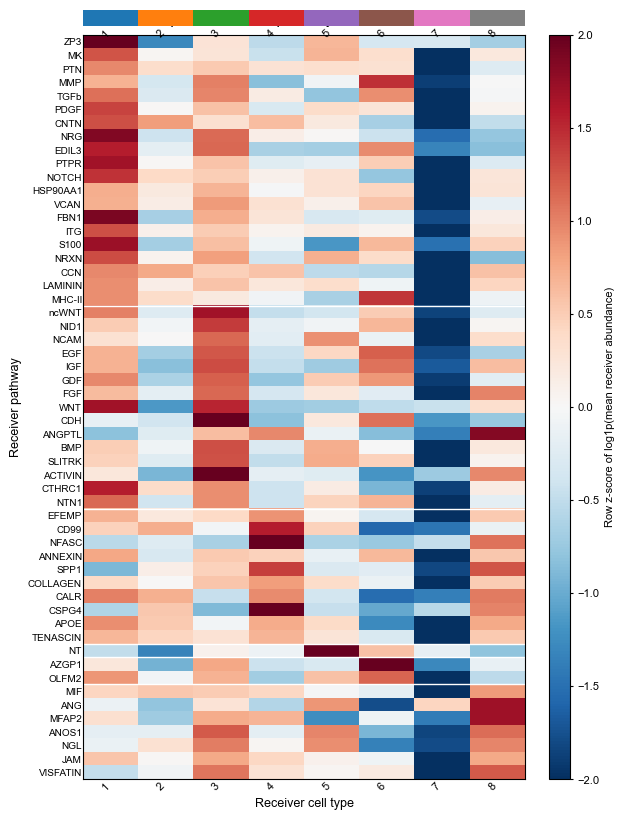

,cluster,pathway,scores,logfoldchanges,pvals,pvals_adj,pct_receiver_spots_positive,pct_receiver_spots_positive_rest,mean_receiver_abundance
0,1,ZP3,20.822870,1.762225,2.686037e-96,9.186246e-94,0.872666,0.493804,3.015372
1,1,MK,20.744017,1.394630,1.388345e-95,2.374070e-93,0.984720,0.882056,18.117250
2,1,PTN,15.001314,0.580977,7.197971e-51,8.205687e-49,0.998302,0.985314,101.936432
3,1,MMP,13.621285,0.894602,2.992540e-42,2.557424e-40,0.952462,0.839376,7.797472
4,1,TGFb,13.605015,0.969103,3.738924e-42,2.557424e-40,0.962649,0.824231,9.599427
5,1,PDGF,13.226028,1.437362,6.208223e-40,3.538687e-38,0.797963,0.553006,6.578989
6,1,CNTN,12.730504,0.748644,4.002446e-37,1.955481e-35,0.988115,0.914181,8.218319
7,1,NRG,12.164639,1.195004,4.795564e-34,2.050103e-32,0.713073,0.427719,1.930714
8,1,EDIL3,11.417621,1.652501,3.414554e-30,1.167778e-28,0.490662,0.205140,0.667411
9,1,PTPR,11.167461,1.036516,5.883847e-29,1.829342e-27,0.772496,0.520422,2.614083


In [16]:
pathway_spot_receiver_mtx = ug.comm.receiver_pathway_spot_matrix(ccc_adata)
(
    cluster_specific_pathways,
    _,
    pathway_receiver_mean_by_type,
    _,
) = ug.comm.rank_cluster_specific_pathways_scanpy(
    pathway_spot_receiver_mtx,
    ccc_adata,
    cluster_key=CLUSTER_KEY,
    top_n=TOP_PATHWAY_PER_CLUSTER,
    method=RANK_METHOD,
    min_pct=MIN_PCT_RECEIVER_SPOTS,
    max_pval_adj=MAX_PVAL_ADJ,
    min_logfoldchange=MIN_LOGFOLDCHANGE,
    fill_top_n_with_unfiltered=FILL_TOP_N_WITH_UNFILTERED,
)

cluster_specific_pathways.to_csv(FIGURE_DIR / 'cluster_specific_receiver_pathways.csv', index=False)
ug.comm.plot_cluster_specific_pathway_marker_heatmap(
    pathway_receiver_mean_by_type,
    cluster_specific_pathways,
    ccc_adata,
    cluster_key=CLUSTER_KEY,
    out_pdf=FIGURE_DIR / 'cluster_specific_receiver_pathway_marker_heatmap.pdf',
)

cluster_specific_pathways.head(20)


## Cluster-Specific Receiver Markers


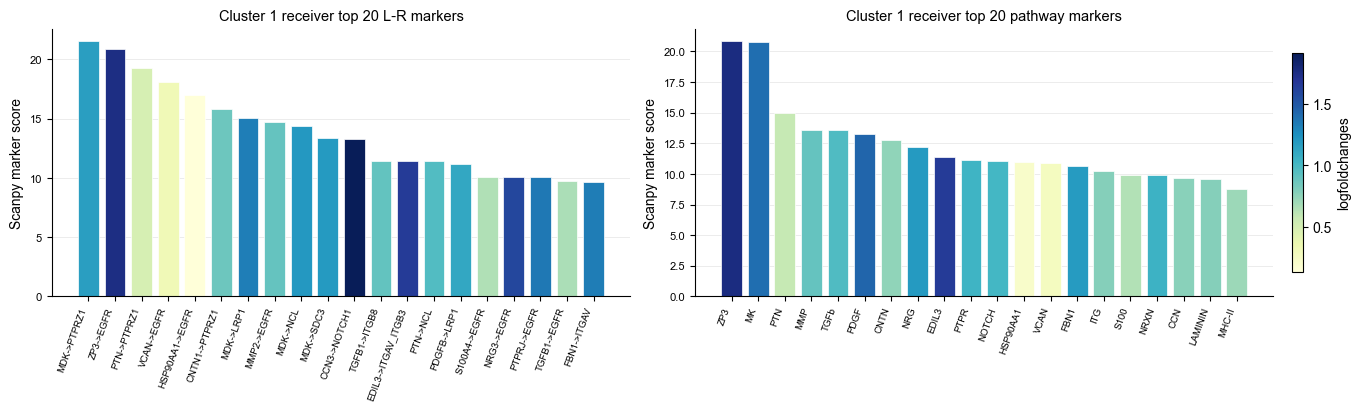

(<Figure size 1350x400 with 3 Axes>,
 array([<Axes: title={'center': 'Cluster 1 receiver top 20 L-R markers'}, ylabel='Scanpy marker score'>,
        <Axes: title={'center': 'Cluster 1 receiver top 20 pathway markers'}, ylabel='Scanpy marker score'>],
       dtype=object))

In [17]:
cluster_receiver_top_lr = ug.comm.extract_cluster_markers(
    cluster_specific_lr_pairs,
    cluster_value=CLUSTER_VALUE,
    feature_col='LR_pair',
    label_col='LR_label',
    top_n=TOP_N_CLUSTER_MARKERS,
)
cluster_receiver_top_pathway = ug.comm.extract_cluster_markers(
    cluster_specific_pathways,
    cluster_value=CLUSTER_VALUE,
    feature_col='pathway',
    label_col='pathway',
    top_n=TOP_N_CLUSTER_MARKERS,
)

cluster_receiver_top_lr.to_csv(FIGURE_DIR / f'cluster{CLUSTER_VALUE}_receiver_LR_markers_scanpy_style.csv', index=False)
cluster_receiver_top_pathway.to_csv(FIGURE_DIR / f'cluster{CLUSTER_VALUE}_receiver_pathway_markers_scanpy_style.csv', index=False)

ug.comm.plot_cluster_marker_score_bars(
    cluster_receiver_top_lr,
    cluster_receiver_top_pathway,
    cluster_value=CLUSTER_VALUE,
    top_n=TOP_N_CLUSTER_MARKERS,
    out_pdf=FIGURE_DIR / f'cluster{CLUSTER_VALUE}_receiver_LR_pathway_markers_scanpy_style.pdf',
)

## Spatial Receiver Scores


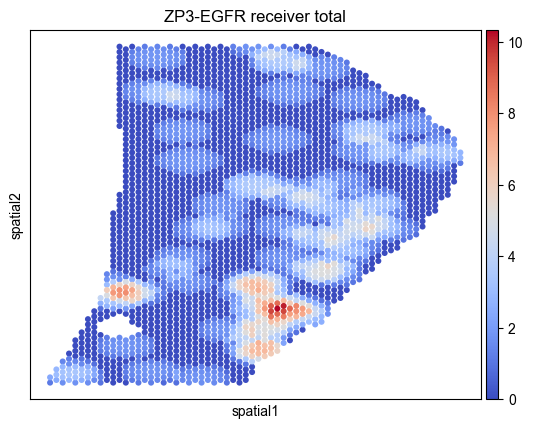

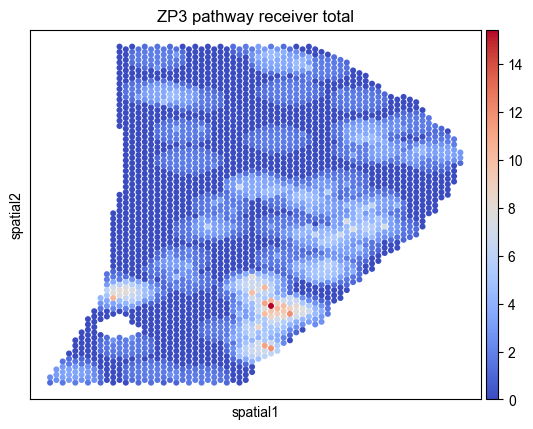

In [18]:
LR_PAIR = 'ZP3|EGFR'
PATHWAY = 'ZP3'

lr_score_key = ug.comm.add_lr_receiver_total(
    ccc_adata,
    LR_PAIR,
    score_key='ZP3_EGFR_receiver_total',
)
ug.comm.plot_spatial_receiver_score(
    ccc_adata,
    lr_score_key,
    basis='spatial',
    size=75,
    title='ZP3-EGFR receiver total',
    cmap='coolwarm',
)

pathway_score_key = ug.comm.add_pathway_receiver_total(
    ccc_adata,
    PATHWAY,
    score_key='ZP3_pathway_receiver_total',
)
ug.comm.plot_spatial_receiver_score(
    ccc_adata,
    pathway_score_key,
    basis='spatial',
    size=75,
    title='ZP3 pathway receiver total',
    cmap='coolwarm',
)
